# Robin Marte – Week 8 Assignment
## Auto MPG dataset cleanup, transformation, visualization, and analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

auto = pd.read_csv(
    url,
    delim_whitespace=True,
    names=column_names,
    na_values="?",
    comment="\t"
)

auto.head()

/tmp/ipykernel_59127/2751706225.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto = pd.read_csv(


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## Reviewing the Data

Next, I'll inspect the dataframe so I can confirm the columns loaded correctly and identify any missing values or data types that need attention.

In [3]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
auto.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


## Cleaning the Horsepower Column

Some values in the horsepower column are marked with a ? instead of a numeric value. I already told pandas to treat ? as a missing value when loading the dataset, so here I'll make sure the column is numeric.

In [5]:
auto["horsepower"] = pd.to_numeric(auto["horsepower"], errors="coerce")

auto["horsepower"].dtype

dtype('float64')

## Transforming the Origin Column

The origin column uses numeric codes:

- 1 = USA
- 2 = Asia
- 3 = Europe

To make the dataset easier to read, I'll replace those codes with the actual region names.

In [6]:
auto["origin"] = auto["origin"].replace({
    1: "USA",
    2: "Asia",
    3: "Europe"
})

auto[["origin"]].head()

,origin
0,USA
1,USA
2,USA
3,USA
4,USA


## Final Check After Cleaning

Before moving into the visualizations, I'll check the dataframe again to make sure the cleaning and transformation were applied correctly.

In [7]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(2), object(2)
memory usage: 28.1+ KB


## Bar Chart: Distribution of Cylinders

This first graphic is a bar chart showing the distribution of cylinders. This helps show how common each cylinder count is in the dataset.

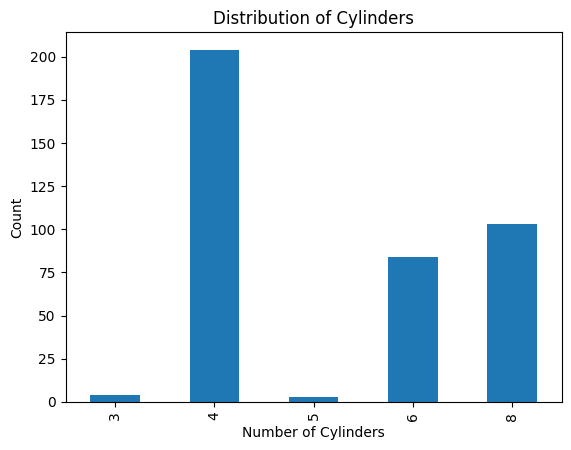

In [8]:
cylinder_counts = auto["cylinders"].value_counts().sort_index()

cylinder_counts.plot(kind="bar")
plt.title("Distribution of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Count")
plt.show()

## Interpretation

The bar chart shows that some cylinder counts appear much more often than others. The most common categories are 4-cylinder, 8-cylinder, and 6-cylinder cars, while 3-cylinder and 5-cylinder cars appear much less frequently.

## Scatterplot: Horsepower and Weight

This second graphic is a scatterplot showing the relationship between horsepower and weight. Before plotting, I'll remove rows with missing horsepower values so the graph doesn't get affected by missing data.

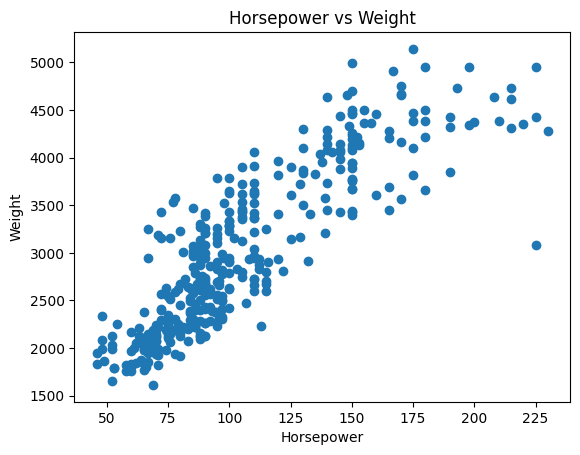

In [9]:
auto_clean = auto.dropna(subset=["horsepower"]).copy()

plt.scatter(auto_clean["horsepower"], auto_clean["weight"])
plt.title("Horsepower vs Weight")
plt.xlabel("Horsepower")
plt.ylabel("Weight")
plt.show()

## Interpretation

The scatterplot shows a positive relationship between horsepower and weight. In general, heavier cars tend to have higher horsepower.

## Additional Question

One question I want to ask is:

Do cars from different origins appear to have different MPG distributions?

A boxplot will be a good way to compare the MPG distributions across the three origin groups.

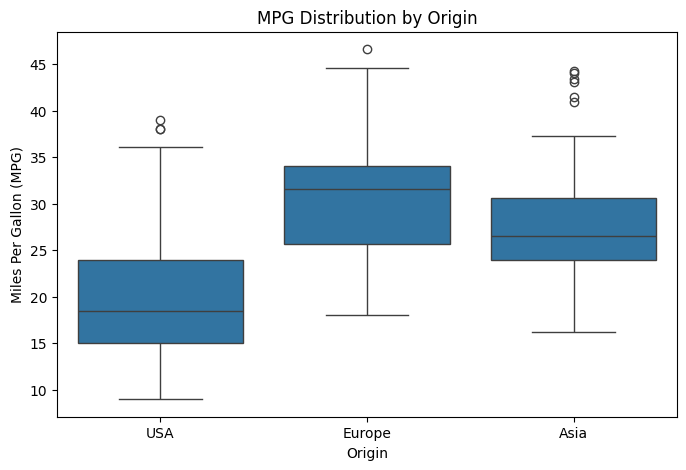

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=auto, x="origin", y="mpg")
plt.title("MPG Distribution by Origin")
plt.xlabel("Origin")
plt.ylabel("Miles Per Gallon (MPG)")
plt.show()

## Interpretation

The boxplot suggests that MPG differs across the three origin groups. Cars from Asia and Europe seem to have higher MPG overall compared to many cars from the USA. The USA group also appears to include more low MPG vehicles.

This suggests that origin may be related to fuel efficiency in this dataset.